# SHAP: what drives the estimate, stage by stage

Three models, each adding features on top of the previous one:

1. **House only**: the house itself (size, rooms, age, lot, type).
2. **+ Neighborhood**: where it is (area, coordinates) and the neighborhood's price level and momentum.
3. **+ Everything else**: accessibility, assigned-school scores, crime, floodplain and light rail.

All three use the same train/test split as `training.py`, so their errors can be compared directly.

**Reading SHAP values.** The models predict `log(1 + total_value)`, so a SHAP value is a change in log value.
For small values it is roughly a percent change: +0.10 means the feature raises the estimate by about 10.5%
for that house compared with the average house.

**Model size.** The production forest (depth 20, 150 trees) is too large for SHAP to explain in reasonable time.
These are smaller forests (depth 18, 100 trees, at least 3 houses per leaf). Their errors are a little higher than
the production numbers in `reports/training_metrics.csv`, but they rank features the same way the stages compare.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor

from src.components.training import (
    CATEGORICAL_FEATURES, FEATURE_COLUMNS, TARGET,
    build_preprocessor, eval_metrics, load_training_data, split_with_aggregates,
)
from src.utils.common import resolve_path
from src.utils.load_config import load_config

cfg = load_config()

/Users/a70411/Let-me-have-a-house/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature groups and stages

In [2]:
FEATURE_GROUPS = {
    "house": ["land_use_class", "acreage", "year_built", "property_age", "heated_area", "bedrooms", "bathrooms"],
    "neighborhood": ["area", "latitude", "longitude", "neighborhood_median_price_per_sqft",
                     "neighborhood_sale_count", "price_momentum"],
    "accessibility": ["education_nearest_miles", "places_count", "health_care_share", "activity_share",
                      "emergency_fire_miles", "emergency_police_miles", "emergency_medical_miles"],
    "school": ["elementary_school_score", "middle_school_score", "high_school_score"],
    "crime": ["violent_crime_rate", "property_crime_rate"],
    "flood_and_rail": ["in_floodplain", "light_rail_miles"],
}
assert sorted(sum(FEATURE_GROUPS.values(), [])) == sorted(FEATURE_COLUMNS)

STAGES = {
    "1. house": ["house"],
    "2. + neighborhood": ["house", "neighborhood"],
    "3. + everything": list(FEATURE_GROUPS),
}

RF_PARAMS = dict(n_estimators=100, max_depth=18, min_samples_leaf=3, max_features=1.0,
                 n_jobs=-1, random_state=cfg["training"]["random_state"])
SHAP_SAMPLE = 500  # test houses explained per stage

## Data

Same rows and split as `training.py`; neighborhood price features are computed from training rows only.

In [3]:
df = load_training_data(resolve_path(cfg, "features_data"))
train, test = split_with_aggregates(df, cfg["training"])
y_train = np.log1p(train[TARGET])
sample = test.sample(SHAP_SAMPLE, random_state=0)
print(f"{len(train):,} training houses, {len(test):,} test houses, {len(sample)} explained")

243,341 training houses, 60,838 test houses, 500 explained


In [4]:
def stage_features(stage):
    return [f for group in STAGES[stage] for f in FEATURE_GROUPS[group]]


def fit_stage(features):
    """Fit one forest on `features`; return (preprocessor, model, test metrics in dollars)."""
    pre = build_preprocessor(features)
    model = RandomForestRegressor(**RF_PARAMS).fit(pre.fit_transform(train[features]), y_train)
    metrics = eval_metrics(test[TARGET], np.expm1(model.predict(pre.transform(test[features]))))
    return pre, model, metrics


def explain(pre, model, features, rows):
    """SHAP values per original feature: the one-hot columns of `area` and `land_use_class`
    are summed back into one value each."""
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(pre.transform(rows[features]))
    names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
    owner = [next(f for f in features if n == f or (f in CATEGORICAL_FEATURES and n.startswith(f + "_")))
             for n in names]
    grouped = pd.DataFrame(values, columns=owner).T.groupby(level=0).sum().T[features]
    # categorical values are shown as codes, only for the beeswarm's colors
    data = rows[features].apply(lambda c: pd.factorize(c)[0] if c.name in CATEGORICAL_FEATURES else c)
    return shap.Explanation(grouped.to_numpy(), base_values=np.full(len(rows), explainer.expected_value[0]),
                            data=data.to_numpy(dtype=float), feature_names=features)


def show(expl, title):
    shap.plots.bar(expl, max_display=15, show=False)
    plt.title(f"{title}: mean |SHAP|")
    plt.show()
    shap.plots.beeswarm(expl, max_display=15, show=False)
    plt.title(f"{title}: SHAP per house")
    plt.show()


def print_metrics(m):
    print(f"MAE ${m['mae']:,.0f}   RMSE ${m['rmse']:,.0f}   R squared {m['r2']:.3f}   average error {m['mape']:.2%}")


results, explanations = {}, {}

## Stage 1: house only

MAE $87,404   RMSE $189,308   R squared 0.760   average error 15.01%


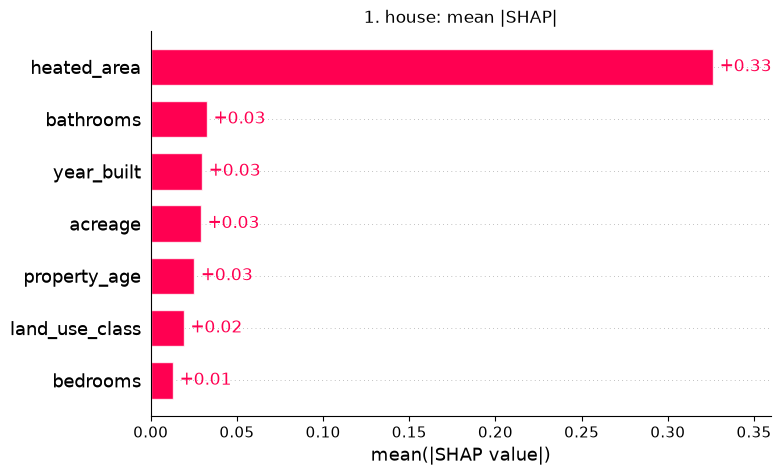

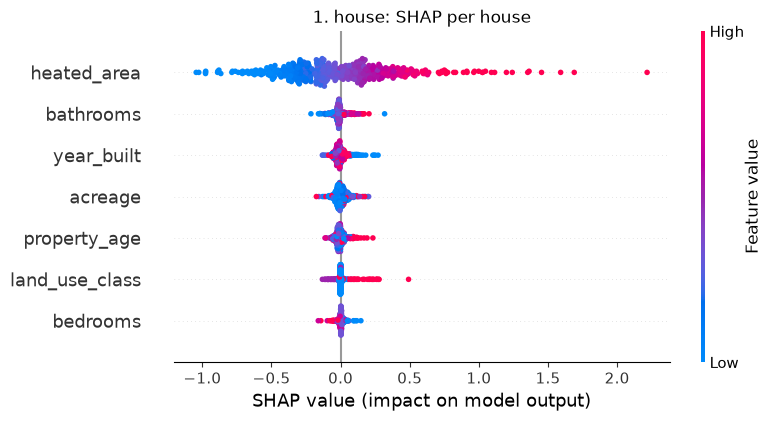

In [5]:
stage = "1. house"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 2: + neighborhood

MAE $35,324   RMSE $103,625   R squared 0.928   average error 6.15%


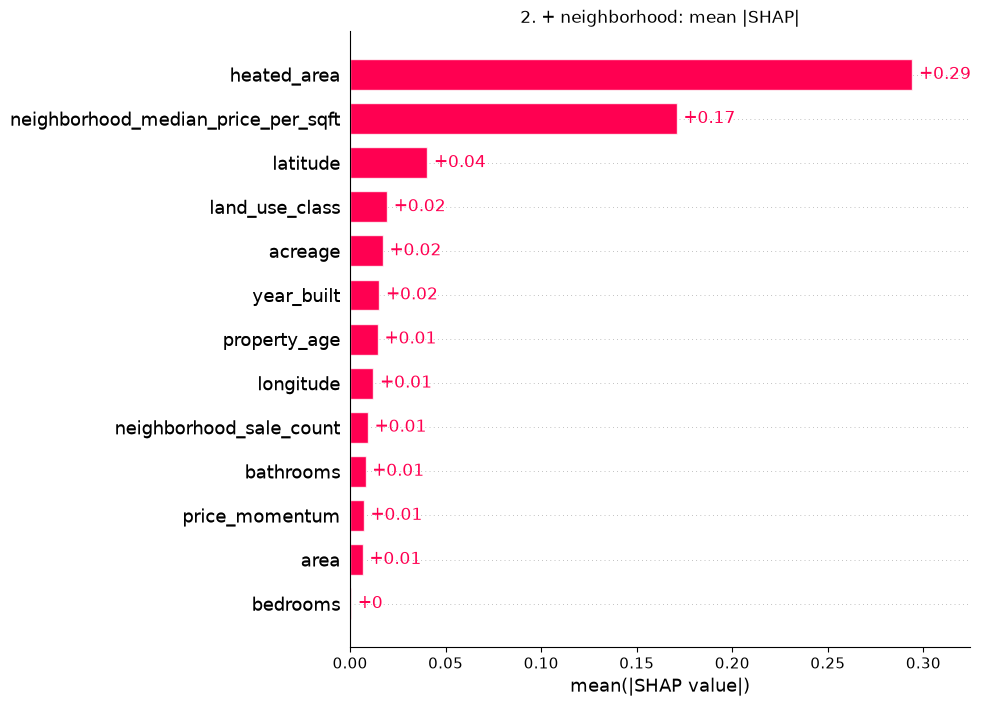

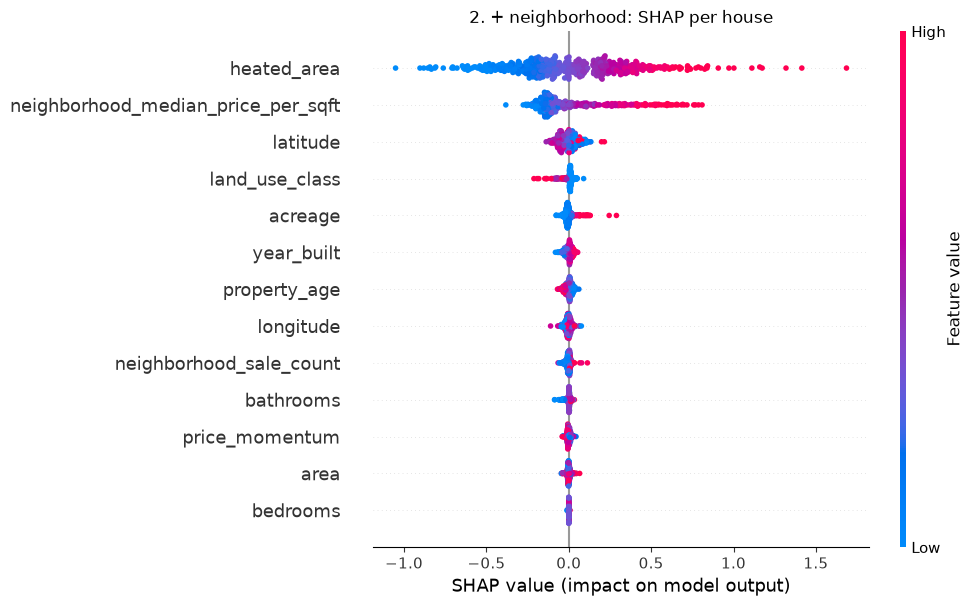

In [6]:
stage = "2. + neighborhood"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 3: + accessibility, school, crime, flood and rail

MAE $34,258   RMSE $102,328   R squared 0.930   average error 5.96%


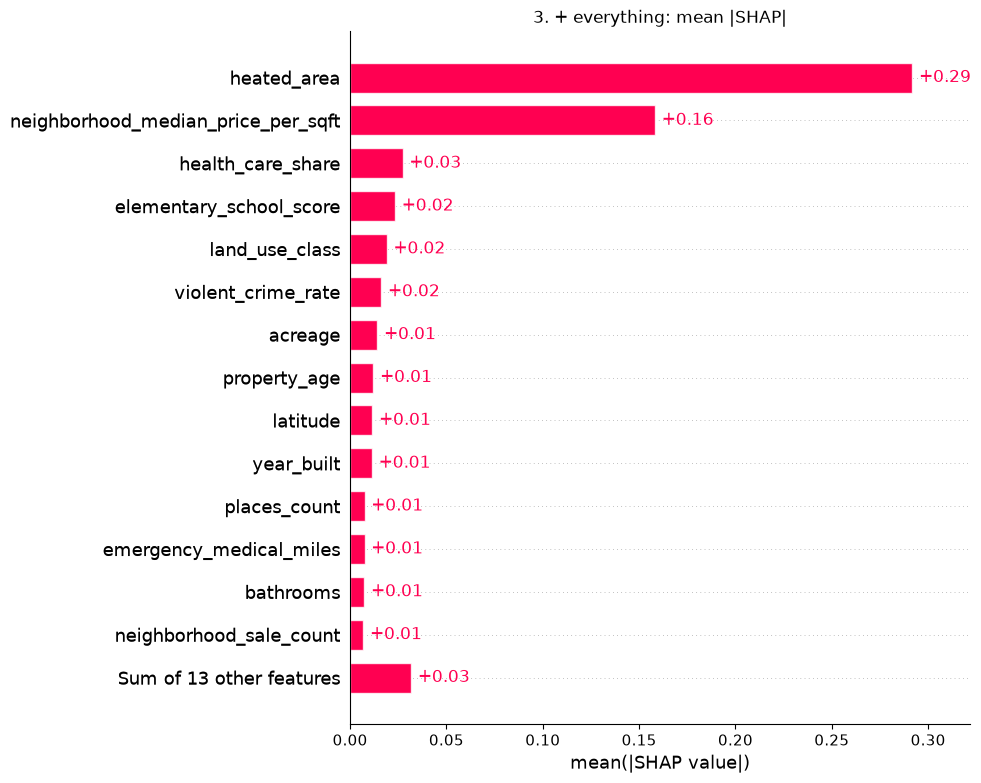

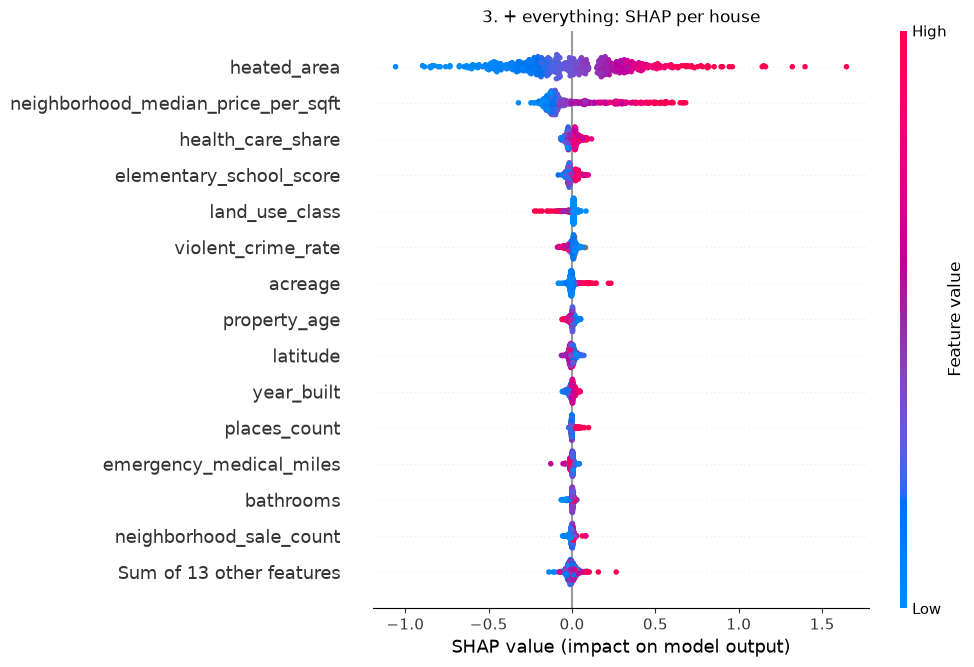

In [7]:
stage = "3. + everything"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Comparison

Test error after each stage, and how much of the stage 3 prediction each feature group carries.

In [8]:
comparison = pd.DataFrame(results).T
comparison["mae"] = comparison["mae"].map("${:,.0f}".format)
comparison["rmse"] = comparison["rmse"].map("${:,.0f}".format)
comparison["mape"] = comparison["mape"].map("{:.2%}".format)
comparison["r2"] = comparison["r2"].round(3)
comparison

,rmse,mae,r2,mape
1. house,"$189,308","$87,404",0.760,15.01%
2. + neighborhood,"$103,625","$35,324",0.928,6.15%
3. + everything,"$102,328","$34,258",0.930,5.96%


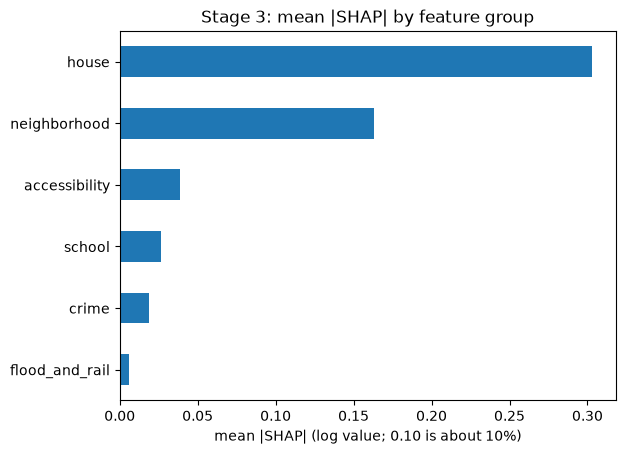

house             0.3030
neighborhood      0.1630
accessibility     0.0384
school            0.0263
crime             0.0185
flood_and_rail    0.0061
dtype: float64

In [9]:
# mean |SHAP| of each group's summed SHAP values, per house
expl = explanations["3. + everything"]
by_feature = pd.DataFrame(expl.values, columns=expl.feature_names)
group_importance = pd.Series({
    group: by_feature[cols].sum(axis=1).abs().mean() for group, cols in FEATURE_GROUPS.items()
}).sort_values()
group_importance.plot.barh(title="Stage 3: mean |SHAP| by feature group")
plt.xlabel("mean |SHAP| (log value; 0.10 is about 10%)")
plt.show()
group_importance.sort_values(ascending=False).round(4)

## The test houses

Why the stage 3 model values each test house (`test_addresses` in `config/config.yaml`) the way it does, starting from the average house.

4817 Kelly Woods Ln, Charlotte NC 28277 - in test set; assessed $1,191,900, stage 3 estimate $1,243,031


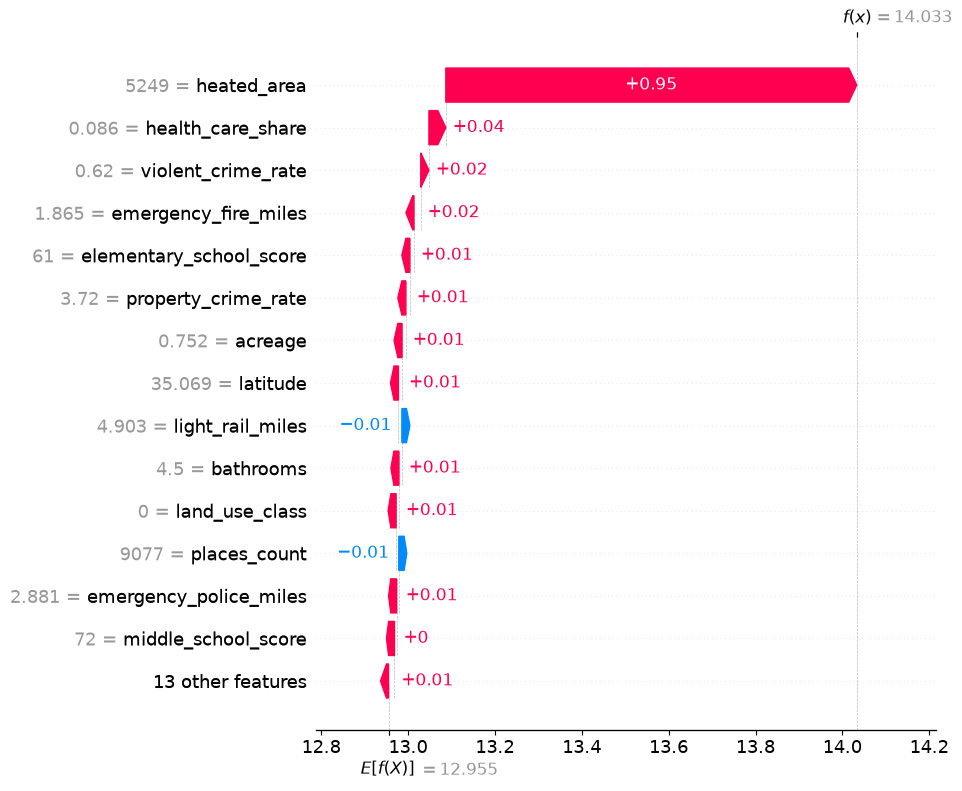

3612 Abbey Hill Ln, Charlotte NC 28210 - in test set; assessed $612,600, stage 3 estimate $619,162


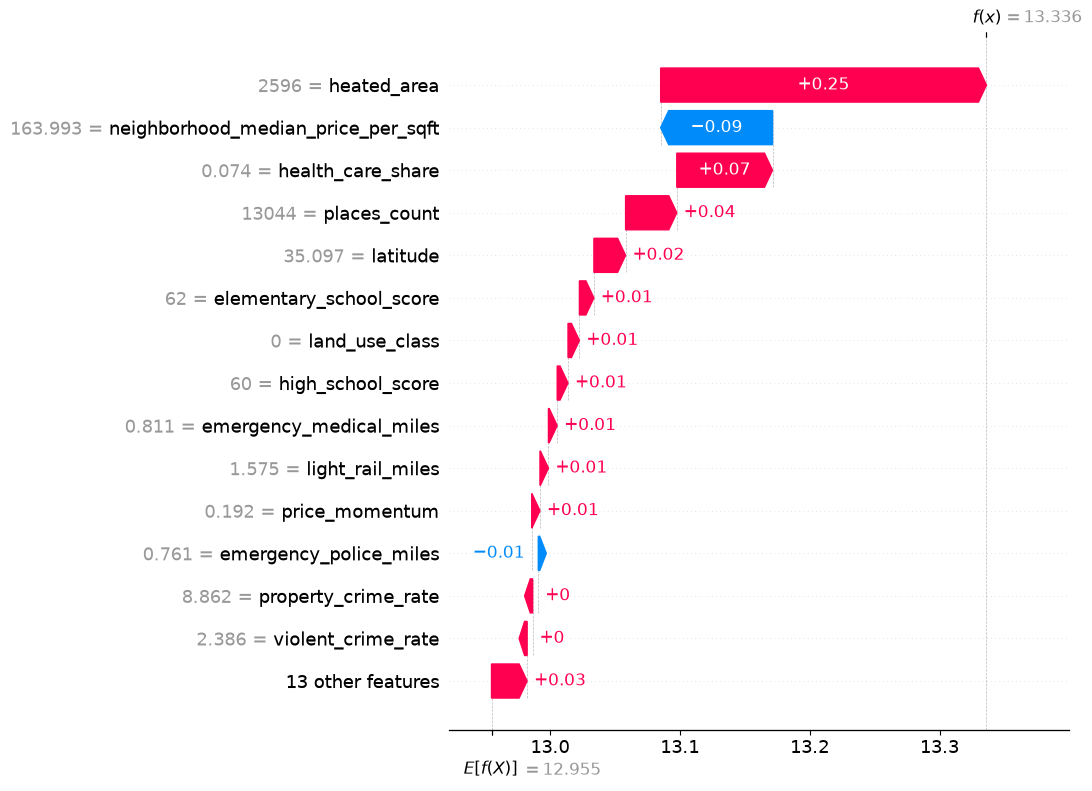

In [10]:
from src.components.search import lookup_property

everything = pd.concat([train, test])
for address in cfg["test_addresses"]:
    parcel = lookup_property(address)[0]["parcel_id"]
    house = everything[everything["parcel_id"] == parcel]
    print(address, "- in", "test" if house.index[0] in test.index else "training", "set;",
          f"assessed ${house[TARGET].iloc[0]:,.0f}, stage 3 estimate "
          f"${np.expm1(model.predict(pre.transform(house[features])))[0]:,.0f}")
    shap.plots.waterfall(explain(pre, model, features, house)[0], max_display=15)

## What this shows

**Test error by stage** (explanation forests; production is MAE $32,826, 5.71%):

| Stage | MAE | Average error | R squared |
|---|---|---|---|
| 1. House only | $87,404 | 15.01% | 0.760 |
| 2. + Neighborhood | $35,324 | 6.15% | 0.928 |
| 3. + Everything else | $34,258 | 5.96% | 0.930 |

1. **The house alone explains most of the variation (R squared 0.76) but misses by 15% on average.** Heated area
   is by far the strongest feature; age, bathrooms and lot size add a little.
2. **Neighborhood is the biggest single improvement**, cutting the error from 15.0% to 6.2%. Almost all of it comes
   from `neighborhood_median_price_per_sqft`. `area` and `price_momentum` add little once that price is known.
3. **Accessibility, school, crime, flood and rail add a small but real gain** (6.15% to 5.96%). In mean |SHAP|:
   accessibility 0.038 (about 4%), school 0.026 (about 3%), crime 0.019 (about 2%), flood and rail 0.006 (under 1%).
   - `health_care_share`, `elementary_school_score` and `violent_crime_rate` are the 3rd, 4th and 6th most
     important features overall, ahead of lot size and age.
   - Directions are as expected: higher school scores raise the estimate, higher violent crime lowers it.
4. **The test houses** (both held out of training):
   - **4817 Kelly Woods Ln**: estimate $1,243,031 against an assessed $1,191,900 (+4.3%). Its size (5,249 sq ft)
     carries almost everything (+0.95). Nearby health care (+0.04) and low violent crime (+0.02) add a little.
     Its neighborhood's price per sq ft adds about nothing: many of the neighborhood's sales are from 2016-2019,
     when prices were much lower.
   - **3612 Abbey Hill Ln**: estimate $619,162 against an assessed $612,600 (+1.1%). Size adds +0.25 and the
     neighborhood price ($164 per sq ft) takes off -0.09. Being close to health care and in a busy area
     (`places_count`) adds +0.11 together.

**Limits**
- SHAP shows what the model relies on, not what causes value. Features that move together (neighborhood price,
  schools, crime) share credit, so a group's number here is smaller than its effect on its own.
- `neighborhood_median_price_per_sqft` is a median over 10 years of sales, so in neighborhoods whose prices rose a
  lot (like Kelly Woods') it understates today's level.
- For the research question (what area and access are worth *without* the neighborhood price), the next step is
  the same analysis on the `without_neighborhood_price` feature set, plus the drop-column test planned in
  `evaluating.py`.
- The beeswarm colors for `area` and `land_use_class` are category codes, not low/high values.
